<a href="https://colab.research.google.com/github/uzmaa29/deeplearning/blob/main/SequenceModelingRNNvsLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df["Month"] = pd.to_datetime(df["Month"])

print(df.head())
print(df.shape)

       Month  Passengers
0 1949-01-01         112
1 1949-02-01         118
2 1949-03-01         132
3 1949-04-01         129
4 1949-05-01         121
(144, 2)


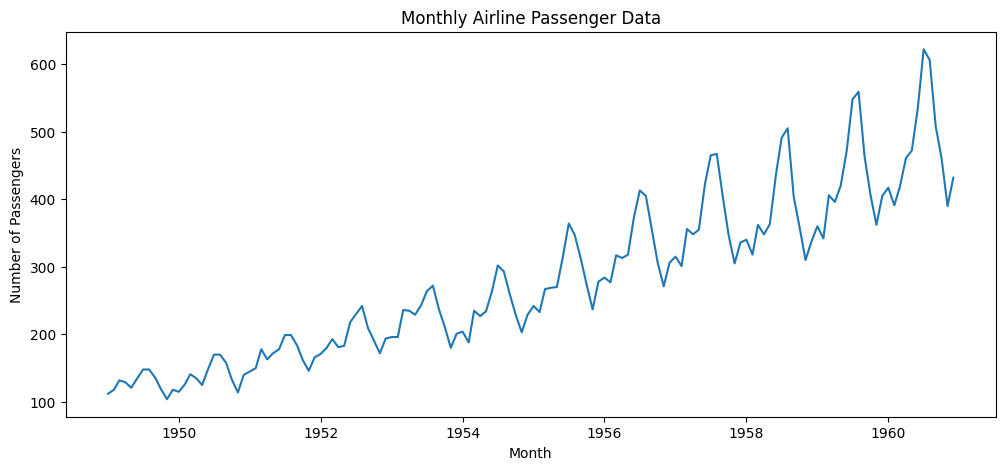

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(df["Month"], df["Passengers"])

plt.title("Monthly Airline Passenger Data")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")

plt.show()

In [7]:
values = df["Passengers"].values.astype("float32")

train_size = int(len(values) * 0.8)

train_values = values[:train_size]
test_values = values[train_size - 12:]

min_value = train_values.min()
max_value = train_values.max()

train_scaled = (train_values - min_value) / (max_value - min_value)

test_scaled = (test_values - min_value) / (max_value - min_value)

In [8]:
def create_sequences(data, window=12):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(data[i-window:i])
        y.append(data[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, 12)

X_test, y_test = create_sequences(test_scaled, 12)

X_train = X_train.reshape(
    (X_train.shape[0], X_train.shape[1], 1)
)

X_test = X_test.reshape(
    (X_test.shape[0], X_test.shape[1], 1)
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (103, 12, 1)
y_train shape: (103,)
X_test shape: (29, 12, 1)
y_test shape: (29,)


In [10]:
rnn_model = Sequential([

    tf.keras.Input(shape=(12, 1)),

    SimpleRNN(
        32,
        activation="tanh"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

rnn_model.compile(
    optimizer="adam",
    loss="mse"
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
rnn_history = rnn_model.fit(

    X_train,
    y_train,

    epochs=50,

    batch_size=16,

    validation_split=0.1,

    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3688 - val_loss: 0.6702
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1452 - val_loss: 0.3544
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0813 - val_loss: 0.2266
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0412 - val_loss: 0.1212
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0186 - val_loss: 0.0498
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0153 - val_loss: 0.0226
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0147 - val_loss: 0.0235
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0100 - val_loss: 0.0348
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - val_loss: 0.0392
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0075 - val_loss: 0.0319
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0063 - val_loss: 0.0221
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0056 - val_loss: 0.0163
E

In [12]:
rnn_pred_scaled = rnn_model.predict(
    X_test,
    verbose=0
)

rnn_pred = (
    rnn_pred_scaled *
    (max_value - min_value)
    + min_value
)

y_test_actual = (
    y_test *
    (max_value - min_value)
    + min_value
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        rnn_pred
    )
)

rnn_mae = mean_absolute_error(
    y_test_actual,
    rnn_pred
)

print("RNN RMSE:", round(rnn_rmse, 2))
print("RNN MAE:", round(rnn_mae, 2))

RNN RMSE: 60.03
RNN MAE: 50.86


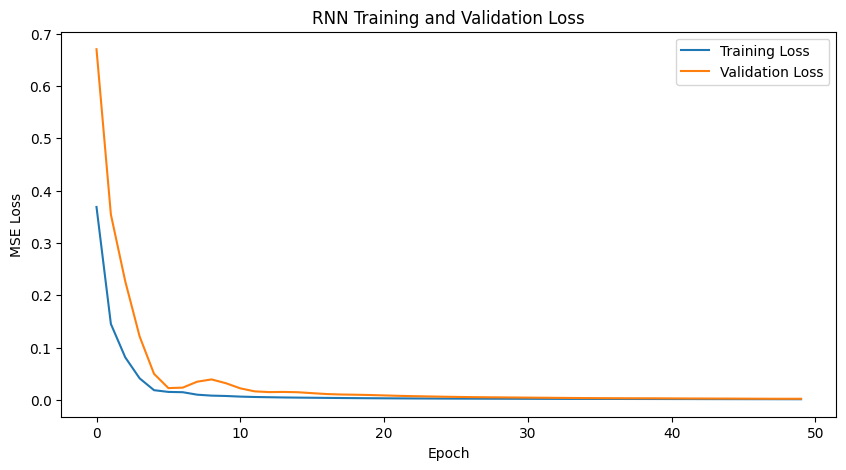

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("RNN Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [14]:
lstm_model = Sequential([

    tf.keras.Input(shape=(12, 1)),

    LSTM(
        32
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
lstm_history = lstm_model.fit(

    X_train,
    y_train,

    epochs=50,

    batch_size=16,

    validation_split=0.1,

    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0869 - val_loss: 0.1524
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0346 - val_loss: 0.0416
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0115 - val_loss: 0.0241
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0156 - val_loss: 0.0265
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0132 - val_loss: 0.0200
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0110 - val_loss: 0.0226
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - val_loss: 0.0202
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0092 - val_loss: 0.0213
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0093 - val_loss: 0.0229
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0092 - val_loss: 0.0215
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0087 - val_loss: 0.0213
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0084 - val_loss: 0.0232
E

In [16]:
lstm_pred_scaled = lstm_model.predict(
    X_test,
    verbose=0
)

lstm_pred = (
    lstm_pred_scaled *
    (max_value - min_value)
    + min_value
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_pred
    )
)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_pred
)

print("LSTM RMSE:", round(lstm_rmse, 2))
print("LSTM MAE:", round(lstm_mae, 2))

LSTM RMSE: 56.16
LSTM MAE: 47.54


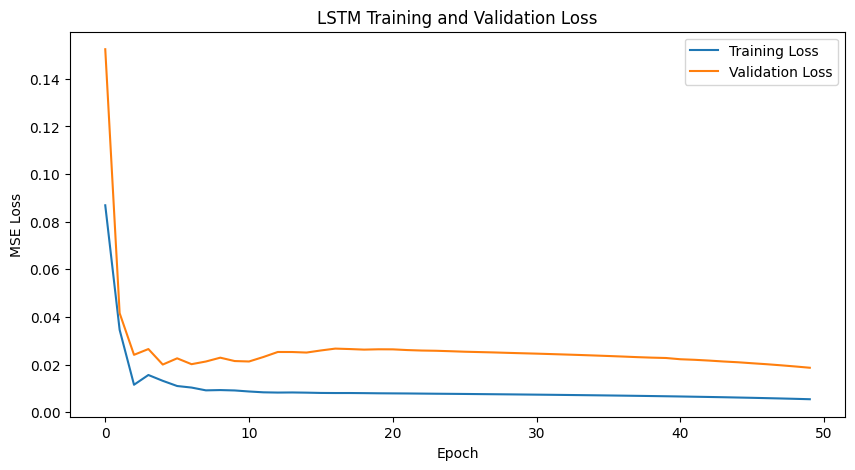

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.show()

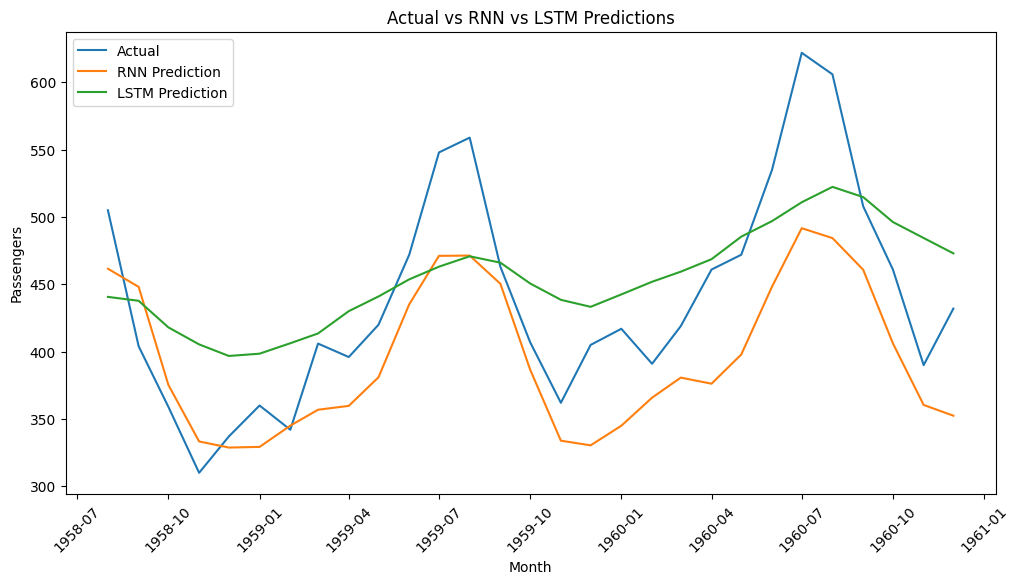

In [18]:
test_dates = df["Month"].iloc[
    train_size:
].reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    y_test_actual,
    label="Actual"
)

plt.plot(
    test_dates,
    rnn_pred.flatten(),
    label="RNN Prediction"
)

plt.plot(
    test_dates,
    lstm_pred.flatten(),
    label="LSTM Prediction"
)

plt.title(
    "Actual vs RNN vs LSTM Predictions"
)

plt.xlabel("Month")

plt.ylabel("Passengers")

plt.legend()

plt.xticks(rotation=45)

plt.show()

In [19]:
comparison = pd.DataFrame({

    "Model": [
        "RNN",
        "LSTM"
    ],

    "RMSE": [
        rnn_rmse,
        lstm_rmse
    ],

    "MAE": [
        rnn_mae,
        lstm_mae
    ]
})

print(comparison)

  Model       RMSE        MAE
0   RNN  60.025127  50.855022
1  LSTM  56.163058  47.543129


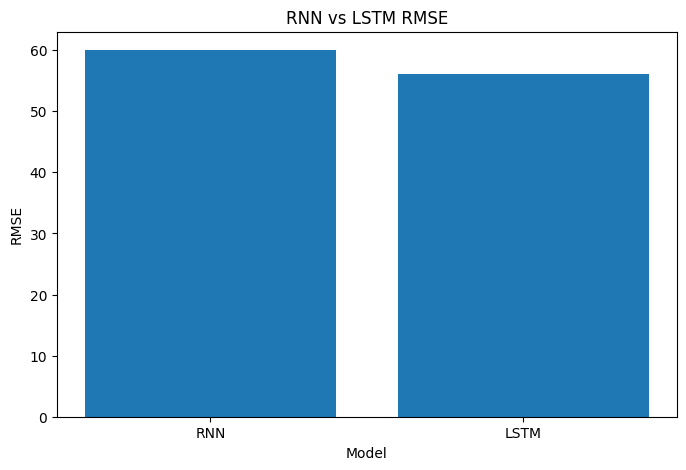

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RNN vs LSTM RMSE")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.show()

In [21]:

print(
    "RNN RMSE:",
    round(rnn_rmse, 2)
)

print(
    "RNN MAE:",
    round(rnn_mae, 2)
)

print(
    "LSTM RMSE:",
    round(lstm_rmse, 2)
)

print(
    "LSTM MAE:",
    round(lstm_mae, 2)
)

if lstm_rmse < rnn_rmse:

    print("\nLSTM performed better than RNN based on RMSE.")

else:

    print("\nRNN performed better than LSTM based on RMSE.")

RNN RMSE: 60.03
RNN MAE: 50.86
LSTM RMSE: 56.16
LSTM MAE: 47.54

LSTM performed better than RNN based on RMSE.


In [22]:
results = pd.DataFrame({

    "Month": test_dates,

    "Actual": y_test_actual.flatten(),

    "RNN Prediction": rnn_pred.flatten(),

    "LSTM Prediction": lstm_pred.flatten()

})

print(results.head(10))

       Month  Actual  RNN Prediction  LSTM Prediction
0 1958-08-01   505.0      461.602753       440.686127
1 1958-09-01   404.0      448.123627       437.771973
2 1958-10-01   359.0      375.286743       418.027222
3 1958-11-01   310.0      333.293823       405.405884
4 1958-12-01   337.0      328.759888       396.799652
5 1959-01-01   360.0      329.250488       398.495514
6 1959-02-01   342.0      345.017944       406.253845
7 1959-03-01   406.0      356.857788       413.536652
8 1959-04-01   396.0      359.726074       430.088623
9 1959-05-01   420.0      380.985657       440.993164


In [23]:
print("""
CONCLUSION

RNN and LSTM models were successfully implemented for sequence prediction
using the Airline Passenger dataset. The models used the previous 12 months
of passenger data to predict the next month's passenger count.

The performance of both models was evaluated using RMSE and MAE. The actual
and predicted values were visualized, and the performance of RNN and LSTM
was compared.

LSTM is designed to handle long-term dependencies more effectively than a
basic RNN because of its memory mechanism.
""")


CONCLUSION

RNN and LSTM models were successfully implemented for sequence prediction
using the Airline Passenger dataset. The models used the previous 12 months
of passenger data to predict the next month's passenger count.

The performance of both models was evaluated using RMSE and MAE. The actual
and predicted values were visualized, and the performance of RNN and LSTM
was compared.

LSTM is designed to handle long-term dependencies more effectively than a
basic RNN because of its memory mechanism.

